# Demo for PresentImages timing
VR Dec 11, 2025

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
import numpy as np

[2025-12-11 18:56:58,276][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


Find and load dataset

In [2]:
df = ra.get_datasets_from_protocol_names('presentimages')
df.tail()


Found 1 protocols matching "presentimages":
['manookinlab.protocols.PresentImages']

Found 41 experiments, 122 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
117,20251015C,data001,1.0,present_images,manookinlab.protocols.PresentImages,1,20251015C/data001,Present Images FW10 + C2,165,16,2641,3986,691
118,20251015C,data004,0.0,present_images,manookinlab.protocols.PresentImages,1,20251015C/data004,Present Images FW0 + C2,165,16,2643,3988,691
119,20251022H,data004,4.0,present_images,manookinlab.protocols.PresentImages,1,20251022H/data004,present images 15 R*,168,16,2668,4024,704
120,20251022H,data012,2.0,present_images,manookinlab.protocols.PresentImages,1,20251022H/data012,present images 6 R*,168,16,2672,4032,704
121,20251106H,data005,4.0,natural_image,manookinlab.protocols.PresentImages,1,20251106H/data005,flashed natural images 4 R*,170,16,2684,4055,716


In [3]:
# Tested for couple datasets
exp_name = '20250306C'
datafile_name = 'data018'

# exp_name = '20251015C'
# datafile_name = 'data004'

sb = ra.MEAStimBlock(exp_name, datafile_name)
rb = ra.MEAResponseBlock(exp_name, datafile_name, b_load_fd=False)

Initializing StimBlock for 20250306C block 3153
Nearest noise chunk for data018 is chunk3 with distance 27 minutes.

Initializing ResponseBlock for 20250306C block 3153
Skipping loading frame monitor data.

Frame Monitor sample rate: 1000.0 Hz
Loading VCD from /Volumes/data-1/data/sorted/20250306C/data018/kilosort2.5 ...
VCD loaded with 907 cells.



I'm using the stim block's `regenerate_stimulus` method to get the onset and offset times of each image flash across epochs. The method calls each image flash a "trial".

In [4]:
help(ra.classes.stim.D_REGEN_FXNS['manookinlab.protocols.PresentImages'])

Help on function load_all_present_images in module retinanalysis.utils.regen:

load_all_present_images(df_epochs: pandas.core.frame.DataFrame, rb: retinanalysis.classes.response.MEAResponseBlock | retinanalysis.classes.response.SCResponseBlock, str_parent_path: str = None, ds_mu: float = 10.0, b_only_timing: bool = False) -> dict
    Load all unique flashed images and their onset/offset timing.
    
    Return dictionary with 'unique_images' array and 'image_names' list.
    
    Args:
        df_epochs (pd.DataFrame): Dataframe of epoch-block metadata.
        rb (MEAResponseBlock | SCResponseBlock): Responseblock with d_timing and amp_sample_rate
        str_parent_path (str, optional): Parent directory to images.
        ds_mu (float, optional): Downscale images to these um-sized pixels. Defaults to 10.0.
        b_only_timing (bool, optional): Return only transition timing. Defaults to False.
    
    Raises:
        ValueError: If multiple magnification factors are found across ep

In [5]:
sb.regenerate_stimulus(b_only_timing=True, rb=rb)

Regenerating stimulus for epochs: [0, 1, 2, 3, 4] in block: 3153
Using regeneration function: load_all_present_images
Using stage frame rate: 59.0 Hz
flashFrames key not found in epoch_parameters. Using old method for transition bins.
Total time: 51.0s, Total frames: 3009, Frame time: 0.0169s
Made state time of shape (3009,)
Number of flashes: 101
Pre bins: 15, Stim bins: 2980, Tail bins: 14
Total bins: 3009
Unique flash bins: (array([6]), array([505]))
Unique gap bins: (array([23, 24]), array([250, 255]))
Pre flash time: 0.2500s
Pre flash bins: 15
Using 13 pre frames, 59.0 Hz stage frame rate.
Protocol had 101 images per epoch, [6] flash frames, [23 24] gap frames.
Found 101 unique images.
Found [5] repeats across all images.
These are named: DovesImages/imk00031.png - DovesImages/imk04205.png
Average empirical frame rate: 59.9448 Hz
Regenerated stimulus with keys: ['all_image_paths', 'u_image_paths', 'repeats', 'trial_image_paths', 'trial_onset_samples', 'trial_offset_samples', 'tria

Text(0.5, 0, 'Time (ms)')

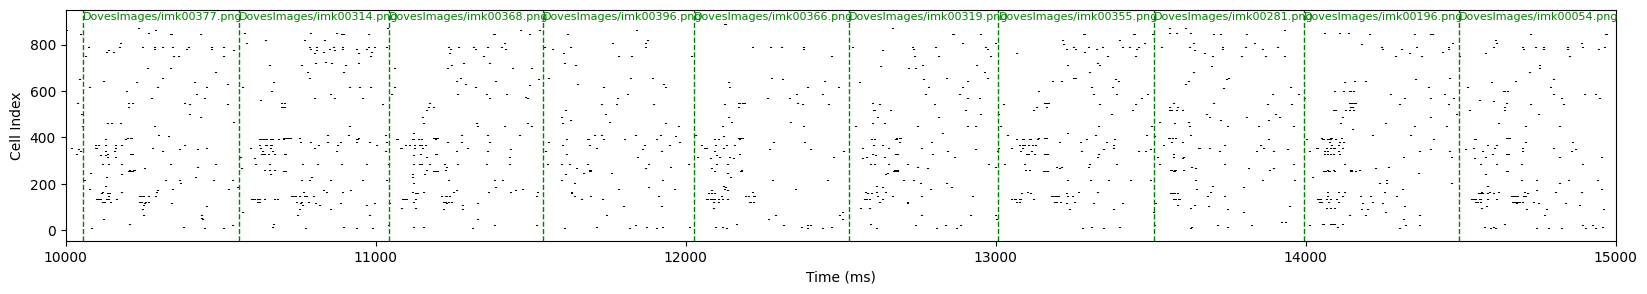

In [6]:
# Plot spike times for all cells and image onsets
d_stim = sb.stim_data

# Selecting first epoch and a time range
epoch_idx = 0
t_min = 10000
t_max = 15000

f, ax = plt.subplots(1, 1, figsize=(20, 3))
n_cells = len(rb.cell_ids)
for cell_idx in range(n_cells):
    sts = rb.df_spike_times.at[cell_idx,'spike_times'][epoch_idx]
    sts = [t for t in sts if t_min <= t <= t_max]
    ax.eventplot(sts, lineoffsets=cell_idx, linelengths=0.5, color='k')

epoch_trials = np.where(d_stim['trial_epoch_idx'] == epoch_idx)[0]
for trial_idx in epoch_trials:
    img_onset_ms = d_stim['trial_onset_ms'][trial_idx]
    img_offset_ms = d_stim['trial_offset_ms'][trial_idx]
    if img_onset_ms < t_min or img_offset_ms > t_max:
        continue
    ax.axvline(x=img_onset_ms, color='g', linestyle='--', lw=1)
    img_path = d_stim['trial_image_paths'][trial_idx]
    ax.text(img_onset_ms, n_cells, img_path, fontsize=8, color='g')
    # ax.axvline(x=img_offset_ms, color='k', linestyle='--', lw=1)

ax.set_xlim(t_min, t_max)
ax.set_ylabel('Cell Index')
ax.set_xlabel('Time (ms)')

## Utility for splitting psth by image

In [64]:
bin_rate = 100
rb.bin_spike_times_at_rate(bin_rate, b_count=False)

Binning spikes for cells:   0%|          | 0/907 [00:00<?, ?it/s]

In [65]:
rb.bin_rate, rb.binned_spikes.shape

(100, (907, 5, 5100))

In [78]:
# Split into (cells, image trials, bins) xarray across all epochs
import xarray as xr
def split_psth_by_trials(sb, rb, pretime_ms=100, posttime_ms=400):
    # pretime_ms: time before image onset to include in the psth
    # posttime_ms: time after image onset to include in the psth
    d_stim = sb.stim_data
    bin_rate = rb.bin_rate
    binned_spikes = rb.binned_spikes
    
    n_cells = len(binned_spikes)
    n_trials = len(d_stim['trial_image_paths'])

    # Bins before and after image onset
    n_prebins = np.floor(pretime_ms / 1e3 * bin_rate).astype(int)
    n_postbins = np.floor(posttime_ms / 1e3 * bin_rate).astype(int)
    n_bins = n_prebins + n_postbins
    # print(f'n_prebins: {n_prebins}, n_postbins: {n_postbins}, n_bins: {n_bins}')

    # Initialize arrays
    split_psth = np.zeros((n_cells, n_trials, n_bins))
    deltas = []
    for i in range(n_trials):
        epoch_idx = d_stim['trial_epoch_idx'][i]
        
        onset_ms = d_stim['trial_onset_ms'][i]
        offset_ms = d_stim['trial_offset_ms'][i]
        onset_bin = np.round(onset_ms / 1e3* bin_rate).astype(int)
        offset_bin = np.round(offset_ms / 1e3 * bin_rate).astype(int)
        deltas.append(offset_bin - onset_bin)
        
        pre_bin_start = onset_bin - n_prebins
        post_bin_end = onset_bin + n_postbins
        
        if pre_bin_start < 0 or post_bin_end > len(binned_spikes[0, epoch_idx]):
            print(f'Skipping trial {i} due to out-of-bounds bin indices')
            continue
        snippet = binned_spikes[:, epoch_idx, pre_bin_start:post_bin_end]
        split_psth[:, i, :] = snippet
    
    # Take avg delta for offset
    n_duration_bins = np.mean(deltas)
    n_duration_bins = np.round(n_duration_bins).astype(int)
    n_duration_ms = n_duration_bins / bin_rate * 1e3
    print(f'Avg flash duration (bins): {n_duration_bins}, (ms): {n_duration_ms}')
    print(f'Variance duration across flashes: {np.var(deltas):.4f}')

    # Create xarray
    cell_ids = rb.cell_ids
    image_paths = d_stim['trial_image_paths']
    n_bin_dt = 1/bin_rate * 1000
    bin_edges = np.arange(-pretime_ms, posttime_ms, n_bin_dt)
    split_psth_xr = xr.DataArray(split_psth, coords=[cell_ids, image_paths, bin_edges], dims=['cell_id', 'image_path', 'time_ms'])
    # Add metadata for onset and offset times
    split_psth_xr.attrs['onset_ms'] = 0
    split_psth_xr.attrs['onset_bins'] = n_prebins
    offset_bins = n_prebins + n_duration_bins
    offset_ms = n_duration_ms
    split_psth_xr.attrs['offset_ms'] = offset_ms
    split_psth_xr.attrs['offset_bins'] = offset_bins
    return split_psth_xr
split_psth_xr = split_psth_by_trials(sb, rb)

Avg flash duration (bins): 10, (ms): 100.0
Variance duration across flashes: 0.0194


Text(0.5, 1.0, 'PSTH for cell 480')

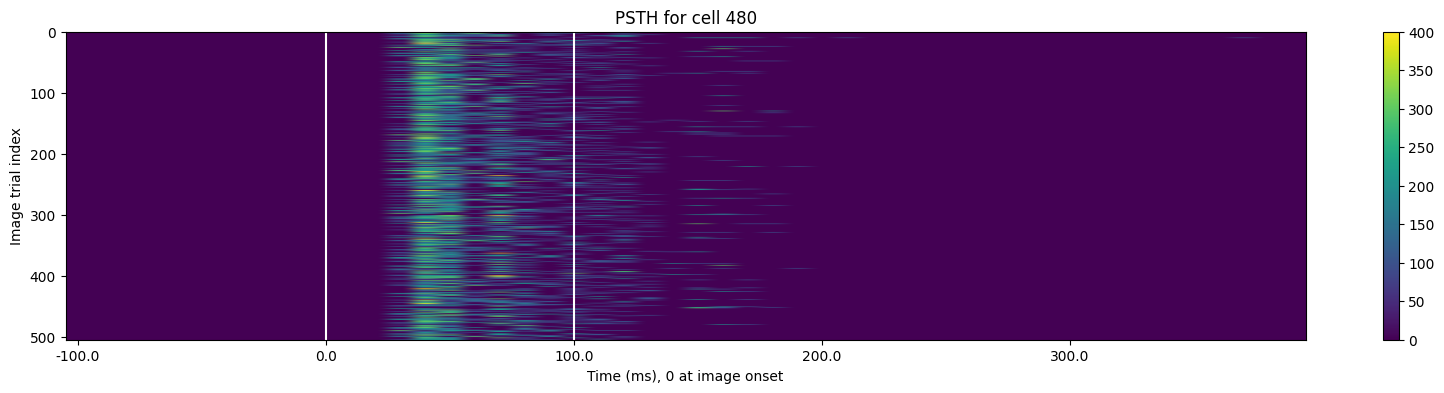

In [79]:
# I happen to know cell 480 is solid Off Parasol
plt.figure(figsize=(20, 4))
im=plt.imshow(split_psth_xr.sel(cell_id=480), aspect='auto')
plt.colorbar(im)
plt.xticks(np.arange(0, len(split_psth_xr['time_ms']), 10), split_psth_xr['time_ms'].values[::10])
plt.axvline(x=split_psth_xr.attrs['onset_bins'], color='w')
plt.axvline(x=split_psth_xr.attrs['offset_bins'], color='w')

plt.xlabel('Time (ms), 0 at image onset')
plt.ylabel('Image trial index')
plt.title('PSTH for cell 480')

Text(0, 0.5, 'Firing rate (Hz)')

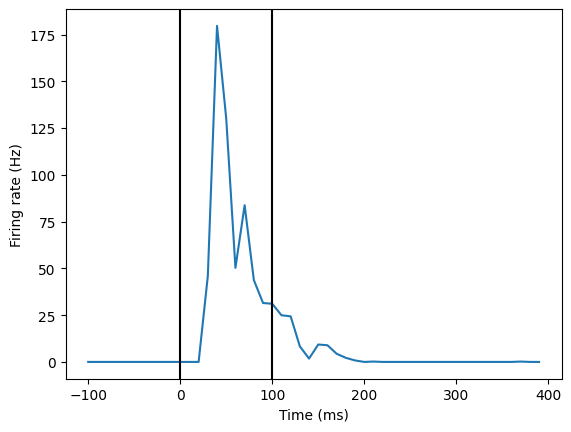

In [82]:
# Average psth across all images
time = split_psth_xr['time_ms'].values
plt.plot(time, split_psth_xr.sel(cell_id=480).mean(dim='image_path'))
plt.axvline(split_psth_xr.attrs['onset_ms'], c='k')
plt.axvline(split_psth_xr.attrs['offset_ms'], c='k')
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')